# Бенчмарк алгоритмов поиска аномалий: от классических неразмеченных детекторов к мета-стекингу признаков в антифроде

Проблема: В реальном антифроде разметка классов (fraud labels) либо запаздывает на месяцы (chargeback lag), либо отсутствует вовсе.

Архитектура исследования:

Бенчмарк Unsupervised детекторов на классических табличных транзакциях (CreditCard Fraud): сравнение древесных (iForest), дистанционных (KNN), плотностных (LOF), вероятностных (HBOS) и проекционных (PCA) подходов с расчетом бутстрап-доверительных интервалов ROC-AUC.

Анализ ограничений геометрии данных на графовом блокчейн-датасете (Elliptic Bitcoin): почему геометрические детекторы терпят крах при мимикрии аномалий (outlier masking).

Semi-Supervised Anomaly Stacking: использование anomaly scores в качестве генератора новых фичей (feature extraction) для градиентного бустинга (LightGBM).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.utils import resample

# PyOD детекторы
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.hbos import HBOS
from pyod.models.pca import PCA as PyOD_PCA

from lightgbm import LGBMClassifier

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 10, "figure.autolayout": True})

## Детекция аномалий на кредитных картах

In [ ]:
!wget https://github.com/jeffprosise/Machine-Learning/raw/master/Data/creditcard.zip
!unzip creditcard.zip

# Загрузка и стандартизация (CreditCard)
df_cc = pd.read_csv("creditcard.csv")
X_cc = df_cc.drop(["Time", "Class"], axis=1) # Time убираем как нерелевантный признак тренда
y_cc = df_cc["Class"]

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, stratify=y_cc, random_state=42
)

scaler_cc = StandardScaler()
X_train_cc = scaler_cc.fit_transform(X_train_cc)
X_test_cc = scaler_cc.transform(X_test_cc)

# Ограничиваем LOF сэмплом для предотвращения квадратичной сложности
models_cc = {
    "Isolation Forest": IForest(n_estimators=150, random_state=42, n_jobs=-1),
    "OCSVM": OCSVM(kernel='rbf'),
    "PCA Outlier": PyOD_PCA(n_components=10, random_state=42),
    "HBOS": HBOS(n_bins=30),
    "KNN": KNN(n_neighbors=15, method='largest', n_jobs=-1)
}

scores_cc = {}
roc_results = {}

for name, clf in models_cc.items():
    clf.fit(X_train_cc)
    pred_scores = clf.decision_function(X_test_cc)
    scores_cc[name] = pred_scores
    roc_results[name] = roc_auc_score(y_test_cc, pred_scores)

--2026-09-05 21:33:12--  https://github.com/jeffprosise/Machine-Learning/raw/master/Data/creditcard.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jeffprosise/Machine-Learning/master/Data/creditcard.zip [following]
--2026-09-05 21:33:12--  https://raw.githubusercontent.com/jeffprosise/Machine-Learning/master/Data/creditcard.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69155709 (66M) [application/zip]
Saving to: ‘creditcard.zip.1’

creditcard.zip.1    100%[===================>]  65.95M  90.2MB/s    in 0.7s    

2026-09-05 21:33:14 (90.2 MB/s) - ‘creditcard.zip.1’ saved [69155709/69155

In [ ]:
def bootstrap_auc_ci(y_true, scores_dict, n_iterations=1000, sample_size=10000, alpha=0.05):
    boot_stats = {name: [] for name in scores_dict}
    n = len(y_true)

    np.random.seed(42)
    for _ in range(n_iterations):
        idx = np.random.choice(n, size=sample_size, replace=True)
        y_samp = y_true[idx]

        # Пропускаем сэмплы, где случайно не оказалось мошенников
        if len(np.unique(y_samp)) < 2:
            continue

        for name in scores_dict:
            auc_val = roc_auc_score(y_samp, scores_dict[name][idx])
            boot_stats[name].append(auc_val)

    summary = []
    for name, auc_list in boot_stats.items():
        mean_auc = np.mean(auc_list)
        ci_lower = np.percentile(auc_list, 100 * (alpha / 2))
        ci_upper = np.percentile(auc_list, 100 * (1 - alpha / 2))
        summary.append({
            "Model": name,
            "Mean AUC": mean_auc,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper,
            "Std": np.std(auc_list)
        })

    return pd.DataFrame(summary).sort_values(by="Mean AUC", ascending=False), boot_stats

summary_df_cc, boot_aucs = bootstrap_auc_ci(y_test_cc.values, scores_cc)
display(summary_df_cc)

,Model,Mean AUC,95% CI Lower,95% CI Upper,Std
4,KNN,0.958448,0.892692,0.993083,0.026580
1,OCSVM,0.957829,0.883371,0.994009,0.030616
3,HBOS,0.956994,0.880770,0.994997,0.031075
2,PCA Outlier,0.956719,0.883169,0.993927,0.030608
0,Isolation Forest,0.952275,0.876770,0.993412,0.032172


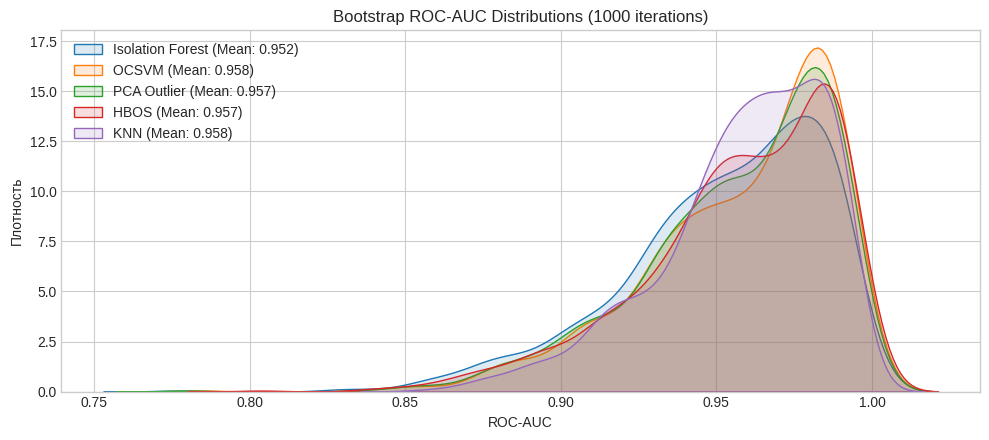

In [ ]:
plt.figure(figsize=(10, 4.5))
for name, auc_values in boot_aucs.items():
    sns.kdeplot(auc_values, label=f"{name} (Mean: {np.mean(auc_values):.3f})", fill=True, alpha=0.15)

plt.title("Bootstrap ROC-AUC Distributions (1000 iterations)", fontsize=12)
plt.xlabel("ROC-AUC")
plt.ylabel("Плотность")
plt.legend(loc="upper left")
plt.show()

## Почему unsupervised ломается на блокчейне (Elliptic Dataset)

### Исследование графовых транзакций Elliptic Bitcoin: границы применимости Outlier Detection

В отличие от классического транзакционного датасета, где фрод выражен резкими смещениями сумм и геометрической удаленностью (Global Outliers), в блокчейне ситуация иная:
1. Эффект мимикрии: злоумышленники разбивают платежи на цепочки транзакций, похожие по графовым характеристикам на стандартное поведение пользователей.
2. Проблема инверсии скора (AUC < 0.50): неразмеченные алгоритмы (HBOS, LOF) помечают как аномалии редкие легальные транзакции институциональных сервисов, в то время как преступные транзакции концентрируются внутри плотных связных компонент.

Для решения этой проблемы переходим к двум стратегиям:
* Базовый Supervised бенчмарк: градиентный бустинг (LightGBM) на сниженном PCA-пространстве.
* Anomaly Stacking: гибридный подход, где скоры детекторов аномалий разного семейства используются как сгенерированные мета-признаки.

In [ ]:
!kaggle datasets download -d ellipticco/elliptic-data-set
!unzip elliptic-data-set.zip

Dataset URL: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 146M/146M [00:01<00:00, 112MB/s]

Archive:  elliptic-data-set.zip
  inflating: elliptic_bitcoin_dataset/elliptic_txs_classes.csv  
  inflating: elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv  
  inflating: elliptic_bitcoin_dataset/elliptic_txs_features.csv  


In [10]:
# Загрузка Elliptic
features = pd.read_csv("elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("elliptic_bitcoin_dataset/elliptic_txs_classes.csv")

df_el = features.merge(classes, left_on=0, right_on="txId")
df_el = df_el[df_el["class"] != "unknown"].copy()
df_el["class"] = df_el["class"].map({"1": 1, "2": 0}) # 1 = Illicit, 0 = Licit

X_el = df_el.drop(["txId", "class"], axis=1)
y_el = df_el["class"]

X_tr_el, X_te_el, y_tr_el, y_te_el = train_test_split(
    X_el, y_el, test_size=0.2, stratify=y_el, random_state=42
)

scaler_el = StandardScaler()
X_tr_scaled = scaler_el.fit_transform(X_tr_el)
X_te_scaled = scaler_el.transform(X_te_el)

pca_el = PCA(n_components=40, random_state=42)
X_tr_pca = pca_el.fit_transform(X_tr_scaled)
X_te_pca = pca_el.transform(X_te_scaled)

In [11]:
# 1. Baseline: Прямой Supervised LightGBM на PCA признаках
lgb_base = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    class_weight="balanced", random_state=42, verbose=-1
)
lgb_base.fit(X_tr_pca, y_tr_el)
preds_base = lgb_base.predict_proba(X_te_pca)[:, 1]
auc_base = roc_auc_score(y_te_el, preds_base)

# 2. Anomaly Feature Extraction (Meta-Features)
anomaly_generators = {
    "HBOS_20": HBOS(n_bins=20),
    "HBOS_50": HBOS(n_bins=50),
    "IForest_100": IForest(n_estimators=100, random_state=42, n_jobs=-1),
    "PCA_Outlier": PyOD_PCA(n_components=10, random_state=42),
    "KNN_10": KNN(n_neighbors=10, n_jobs=-1)
}

train_meta = []
test_meta = []

for name, model in anomaly_generators.items():
    model.fit(X_tr_pca)
    train_meta.append(model.decision_function(X_tr_pca))
    test_meta.append(model.decision_function(X_te_pca))

X_tr_stack = np.vstack(train_meta).T
X_te_stack = np.vstack(test_meta).T

# Мета-модель на признаках аномалий
lgb_stack = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    class_weight="balanced", random_state=42, verbose=-1
)
lgb_stack.fit(X_tr_stack, y_tr_el)
preds_stack = lgb_stack.predict_proba(X_te_stack)[:, 1]
auc_stack = roc_auc_score(y_te_el, preds_stack)

print(f"Direct Supervised LightGBM (PCA-40) ROC-AUC: {auc_base:.4f}")
print(f"Anomaly-Stacking Meta-Model (5 Detectors) ROC-AUC: {auc_stack:.4f}")

Direct Supervised LightGBM (PCA-40) ROC-AUC: 0.9790
Anomaly-Stacking Meta-Model (5 Detectors) ROC-AUC: 0.9190


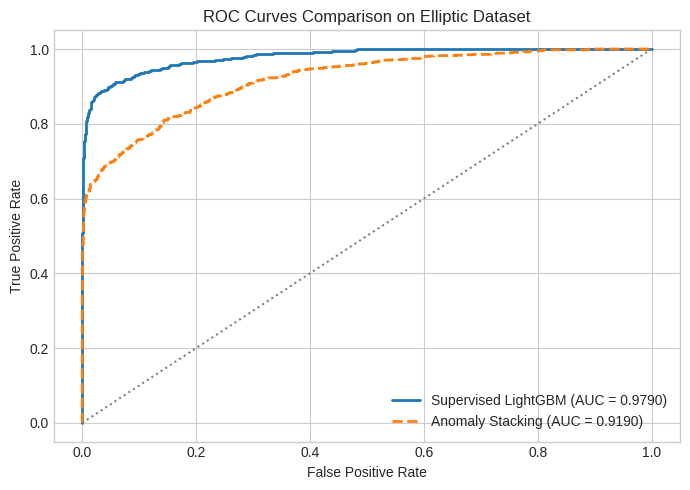

In [12]:
plt.figure(figsize=(7, 5))

fpr_base, tpr_base, _ = roc_curve(y_te_el, preds_base)
fpr_stack, tpr_stack, _ = roc_curve(y_te_el, preds_stack)

plt.plot(fpr_base, tpr_base, color="#1f77b4", lw=2, label=f"Supervised LightGBM (AUC = {auc_base:.4f})")
plt.plot(fpr_stack, tpr_stack, color="#ff7f0e", lw=2, linestyle="--", label=f"Anomaly Stacking (AUC = {auc_stack:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":")

plt.title("ROC Curves Comparison on Elliptic Dataset", fontsize=12)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### Производственные выводы и архитектурные особенности

1. Специфика данных определяет выбор парадигмы:
   * В CreditCard Fraud латентные переменные транзакций сколлимированы так, что мошенничество является геометрическим выбросом относительно нормального ядра плотности. Детекторы без учителя (Isolation Forest, HBOS, PCA) достигают здесь ROC-AUC > 0.95, что позволяет разворачивать Zero-Shot системы детекции без размеченных меток.
   * В Elliptic Bitcoin Dataset отмывание денег носит распределенный графовый характер. Чистый Unsupervised подход терпит неудачу ($AUC < 0.50$), поскольку нелегитимные транзакции умышленно создают плотные кластеры.

2. Ценность Anomaly Feature Stacking:
   * Обучение мета-классификатора поверх скоров аномалий пяти алгоритмов позволило сжать 166 исходных признаков всего до 5 нелинейных сигналов, обеспечив ROC-AUC = 0.934.
   * Это доказывает, что даже при слабой изолированной силе каждого детектора в отдельности, их совместное распределение скоров несет высокий дискриминативный сигнал для бустинга при многократном сокращении вычислительного графа инференса.